In [1]:
# ============================================================
# MAPCT-v3.5 — Mechanism-Aware Patient–Clinical Transformer
# Joint latent reconstruction + class-weighted BCE + latent viz
# ============================================================

# 1️⃣ IMPORTS + DETERMINISM
# ------------------------------------------------------------
import os, random, re
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cpu


In [2]:


# 2️⃣ LOAD DATA
# ------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

clinic_df = pd.read_excel(file_path1)
mech_df   = pd.read_excel(file_path2)  # drug mechanism

Mounted at /content/drive


In [3]:

# 3️⃣ DRUG STRING NORMALIZATION
# ------------------------------------------------------------
def normalize_drug_name(name: str) -> str:
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    name = re.sub(r"\([^)]*\)", "", name)
    name = re.sub(r"\s+brand:.*", "", name)
    name = re.sub(r"\s*\+\s*", ", ", name)
    name = re.sub(r"\s*,\s*", ", ", name)
    return name.strip()

def sort_drug_combo(combo: str) -> str:
    if not isinstance(combo, str):
        return ""
    drugs = sorted(d.strip() for d in combo.split(",") if d.strip())
    return ", ".join(drugs)

clinic_df["merged_drugs_norm"] = (
    clinic_df["merged_drugs"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
)

# 4️⃣ LEAK-FREE CLINICAL PREPROCESSING + SPLIT
# ------------------------------------------------------------
numeric_cols = ["fbs", "glu", "hba1c", "TG", "cho", "LDL", "HDL",
                "UA", "Na", "K", "Ca", "Vit D", "age"]
categorical_cols = ["sex", "fbs_category", "tg_category", "cho_category"]

clinic_df = clinic_df.dropna(subset=numeric_cols + categorical_cols).reset_index(drop=True)

from sklearn.model_selection import GroupShuffleSplit

# Groups = unique drug combination strings
groups = clinic_df["merged_drugs_norm"]

# First split: separate test set (20% of groups)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_val, idx_test = next(gss1.split(clinic_df, groups=groups))

# Second split: from remaining groups, take 20% for validation (→ 16% of total patients)
groups_train_val = groups.iloc[idx_train_val]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_rel, idx_val_rel = next(gss2.split(clinic_df.iloc[idx_train_val], groups=groups_train_val))

# Convert relative indices to original indices
idx_train = idx_train_val[idx_train_rel]
idx_valid = idx_train_val[idx_val_rel]
idx_test = idx_test  # already from first split

# Create dataframes (keep original indices for later reference)
train_df = clinic_df.iloc[idx_train].reset_index(drop=True)
valid_df = clinic_df.iloc[idx_valid].reset_index(drop=True)
test_df  = clinic_df.iloc[idx_test].reset_index(drop=True)

# Store original indices if needed for mapping (optional)
idx_train_original = idx_train
idx_valid_original = idx_valid
idx_test_original = idx_test

print("Split sizes (leakage‑free):", len(train_df), len(valid_df), len(test_df))

# Sanity check: no drug combination appears in both train and test
train_combos = set(clinic_df.iloc[idx_train]["merged_drugs_norm"])
test_combos = set(clinic_df.iloc[idx_test]["merged_drugs_norm"])
assert len(train_combos & test_combos) == 0, "Leakage detected!"
print("✅ Leakage‑free split verified: train and test have no common regimens.")


Split sizes (leakage‑free): 3052 545 950
✅ Leakage‑free split verified: train and test have no common regimens.


In [4]:

# 5️⃣ BUILD DRUG VOCAB FROM TRAIN ONLY
# ------------------------------------------------------------
all_drugs_train = sorted({
    d for combo in train_df["merged_drugs_norm"] for d in combo.split(",") if d.strip()
})
drug_to_idx = {drug: i+1 for i, drug in enumerate(all_drugs_train)}
num_drugs = len(all_drugs_train)+1
print("num_drugs:", num_drugs)

def filter_to_train_vocab(combo: str) -> str:
    if not isinstance(combo, str):
        return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    filtered = [d for d in drugs if d in drug_to_idx]
    return ", ".join(sorted(filtered))

valid_df["merged_drugs_norm"] = valid_df["merged_drugs_norm"].apply(filter_to_train_vocab)
test_df["merged_drugs_norm"]  = test_df["merged_drugs_norm"].apply(filter_to_train_vocab)

num_drugs: 198


In [5]:

# 6️⃣ CLINICAL SCALING (FIT ON TRAIN ONLY)
# ------------------------------------------------------------
scaler = StandardScaler()
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_num_train = scaler.fit_transform(train_df[numeric_cols])
X_cat_train = ohe.fit_transform(train_df[categorical_cols])

X_num_valid = scaler.transform(valid_df[numeric_cols])
X_cat_valid = ohe.transform(valid_df[categorical_cols])

X_num_test  = scaler.transform(test_df[numeric_cols])
X_cat_test  = ohe.transform(test_df[categorical_cols])

X_clin_train = np.hstack([X_num_train, X_cat_train])
X_clin_valid = np.hstack([X_num_valid, X_cat_valid])
X_clin_test  = np.hstack([X_num_test,  X_cat_test])

clin_dim = X_clin_train.shape[1]
print("Train clinical shape:", X_clin_train.shape)
print("Test clinical shape:",  X_clin_test.shape)

assert X_clin_train.shape[1] == X_clin_valid.shape[1] == X_clin_test.shape[1]

Train clinical shape: (3052, 25)
Test clinical shape: (950, 25)


In [6]:
# 7️⃣ DRUG SEQUENCE MATRICES
# ------------------------------------------------------------
max_drugs_in_combo = max(len(c.split(",")) for c in train_df["merged_drugs_norm"])

def build_drug_sequence(df):
    seq = np.zeros((len(df), max_drugs_in_combo), dtype=np.int64)
    for i, combo in enumerate(df["merged_drugs_norm"]):
        drugs = [d.strip() for d in combo.split(",") if d.strip()]
        for j, d in enumerate(drugs[:max_drugs_in_combo]):
            seq[i, j] = drug_to_idx.get(d, 0)
    return seq

drug_ids_train = build_drug_sequence(train_df)
drug_ids_valid = build_drug_sequence(valid_df)
drug_ids_test  = build_drug_sequence(test_df)

# 7b️⃣ MULTI-HOT TARGETS FOR DRUG PREDICTION
# ------------------------------------------------------------
def build_multi_hot(df):
    X = np.zeros((len(df), num_drugs), dtype=np.float32)
    for i, combo in enumerate(df["merged_drugs_norm"]):
        for d in combo.split(","):
            d = d.strip()
            if d in drug_to_idx:
                X[i, drug_to_idx[d]] = 1.0
    return X

X_drug_train = build_multi_hot(train_df)
X_drug_valid = build_multi_hot(valid_df)
X_drug_test  = build_multi_hot(test_df)


In [7]:

# 8️⃣ MECHANISM TABLE NORMALIZATION (MULTI-HOT, LEAK-FREE)
# ------------------------------------------------------------

# Normalize drug names
mech_df["Drug Name Norm"] = (
    mech_df["Drug Name"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
)

# Drop duplicates
mech_df = mech_df.drop_duplicates(subset=["Drug Name Norm"]).reset_index(drop=True)

# Identify mechanism columns (exclude identifiers)
mech_cols = [
    c for c in mech_df.columns
    if c not in ["Drug Name", "Drug Name Norm", "ChEMBL ID"]
]

# Split into numeric vs text columns
text_cols = []
numeric_cols_mech = []

for c in mech_cols:
    if mech_df[c].dtype == object:
        text_cols.append(c)
    else:
        numeric_cols_mech.append(c)

# -------------------------------
# STEP 2 — TRAIN-ONLY VOCABULARY
# -------------------------------
train_drugs = set(train_df["merged_drugs_norm"])

mech_train = mech_df[mech_df["Drug Name Norm"].isin(train_drugs)].copy()

vocab = {}

for col in text_cols:
    vocab[col] = sorted({
        token.strip()
        for cell in mech_train[col].astype(str)
        for token in re.split(r"[;,|]", cell)
        if token.strip() not in ["", "nan"]
    })

# -------------------------------
# STEP 3 — MULTI-HOT ENCODING
# -------------------------------
def encode_multihot(cell, vocab_list):
    vec = np.zeros(len(vocab_list), dtype=np.float32)
    if not isinstance(cell, str):
        return vec
    tokens = [t.strip() for t in re.split(r"[;,|]", cell) if t.strip()]
    for t in tokens:
        if t in vocab_list:
            vec[vocab_list.index(t)] = 1.0
    return vec

# -------------------------------
# STEP 4 — BUILD FINAL MATRIX
# -------------------------------
mech_features = []

for idx, row in mech_df.iterrows():
    row_vec = []

    # numeric columns
    for c in numeric_cols_mech:
        row_vec.append(float(row[c]))

    # multi-hot text columns
    for c in text_cols:
        row_vec.extend(encode_multihot(row[c], vocab[c]))

    mech_features.append(row_vec)

mech_features = np.array(mech_features, dtype=np.float32)

# -------------------------------
# STEP 5 — REPLACE mech_df CONTENT
# -------------------------------
mech_df_numeric = pd.DataFrame(mech_features)
mech_cols = list(mech_df_numeric.columns)

mech_df = pd.concat([mech_df[["Drug Name Norm"]], mech_df_numeric], axis=1)
mech_dim = len(mech_cols)

# -------------------------------
# STEP 6 — GLOBAL SCALING (SAFE)
# -------------------------------
mech_scaler = MinMaxScaler()
mech_scaler.fit(mech_df_numeric)

mech_df_numeric = mech_scaler.transform(mech_df_numeric)
mech_df_numeric = np.clip(mech_df_numeric, 0.0, 1.0)
mech_df_numeric += 1e-6

# Replace numeric part
mech_df[mech_cols] = mech_df_numeric


In [8]:
# 🔍 Inspect mechanism vocabularies
def print_mech_vocab(vocab, max_items=20):
    print("=== Mechanism Vocabulary Summary ===")
    for col, tokens in vocab.items():
        print(f"\nColumn: {col}")
        print(f"Total tokens: {len(tokens)}")
        print("Sample tokens:")
        for t in tokens[:max_items]:
            print("  -", t)
        if len(tokens) > max_items:
            print(f"  ... (+{len(tokens) - max_items} more)")


In [9]:
# 🔍 Inspect mechanism vocabularies
print_mech_vocab(vocab)

=== Mechanism Vocabulary Summary ===

Column: Site of Action
Total tokens: 13
Sample tokens:
  - ACE enzyme in vascular endothelium
  - Bacterial DNA gyrase and topoisomerase IV
  - CNS dopamine D2
  - CNS α2-adrenergic receptors
  - Cardiac β1-adrenergic receptors
  - Hepatic HMG-CoA reductase
  - Hepatic PPAR-α nuclear receptors
  - Hepatic mitochondria (complex I)
  - Intestinal brush border (α-glucosidase)
  - Nuclear glucocorticoid receptors
  - Pancreatic β-cell sulfonylurea receptor (SUR1)
  - Vascular smooth muscle (L-type Ca²⁺ channels)
  - serotonin 5-HT2A receptors

Column: Downstream Effectors
Total tokens: 13
Sample tokens:
  - ↑ insulin secretion → ↓ blood glucose
  - ↑ lipolysis → ↓ triglycerides → ↑ HDL
  - ↓ Angiotensin II → ↓ vasoconstriction → ↓ blood pressure
  - ↓ Ca²⁺ influx → ↓ vascular tone → ↓ blood pressure
  - ↓ DNA replication → ↑ bacterial death
  - ↓ Glucose absorption → ↓ postprandial glycemia
  - ↓ Mevalonate → ↓ cholesterol synthesis → ↑ LDL receptor ex

In [10]:

# 9️⃣ MECHANISM TENSORS ALIGNED TO PATIENTS
# ------------------------------------------------------------
max_drugs_in_combo = max(len(c.split(",")) for c in train_df["merged_drugs_norm"])

def build_mech_tensor(df):
    X_mech = np.zeros((len(df), max_drugs_in_combo, mech_dim), dtype=np.float32)
    for i, combo in enumerate(df["merged_drugs_norm"]):
        drugs = [d.strip() for d in combo.split(",") if d.strip()]
        for j, d in enumerate(drugs[:max_drugs_in_combo]):
            row = mech_df.loc[mech_df["Drug Name Norm"] == d]
            if not row.empty:
                mech_vec = row[mech_cols].values.squeeze()
                X_mech[i, j, :] = mech_vec
    return X_mech

X_mech_train = build_mech_tensor(train_df)
X_mech_valid = build_mech_tensor(valid_df)
X_mech_test  = build_mech_tensor(test_df)

assert X_clin_train.shape[1] == X_clin_valid.shape[1] == X_clin_test.shape[1]

# 🔟 TORCH TENSORS
# ------------------------------------------------------------
y_drug_train = torch.tensor(X_drug_train, dtype=torch.float32)
y_drug_valid = torch.tensor(X_drug_valid, dtype=torch.float32)
y_drug_test  = torch.tensor(X_drug_test,  dtype=torch.float32)

y_clin_train = torch.tensor(X_clin_train, dtype=torch.float32)
y_clin_valid = torch.tensor(X_clin_valid, dtype=torch.float32)
y_clin_test  = torch.tensor(X_clin_test,  dtype=torch.float32)

X_drug_tensor_train = torch.tensor(drug_ids_train, dtype=torch.long)
X_drug_tensor_valid = torch.tensor(drug_ids_valid, dtype=torch.long)
X_drug_tensor_test  = torch.tensor(drug_ids_test,  dtype=torch.long)

X_role_tensor_train = torch.zeros_like(X_drug_tensor_train, dtype=torch.long)
X_role_tensor_valid = torch.zeros_like(X_drug_tensor_valid, dtype=torch.long)
X_role_tensor_test  = torch.zeros_like(X_drug_tensor_test,  dtype=torch.long)

X_drug_mask_train = (X_drug_tensor_train > 0).long()
X_drug_mask_valid = (X_drug_tensor_valid > 0).long()
X_drug_mask_test  = (X_drug_tensor_test  > 0).long()

X_mech_tensor_train = torch.tensor(X_mech_train, dtype=torch.float32)
X_mech_tensor_valid = torch.tensor(X_mech_valid, dtype=torch.float32)
X_mech_tensor_test  = torch.tensor(X_mech_test,  dtype=torch.float32)

X_clin_tensor_train = torch.tensor(X_clin_train, dtype=torch.float32)
X_clin_tensor_valid = torch.tensor(X_clin_valid, dtype=torch.float32)
X_clin_tensor_test  = torch.tensor(X_clin_test,  dtype=torch.float32)

# 1️⃣1️⃣ DATASETS & LOADERS
# ------------------------------------------------------------
BATCH = 128

g = torch.Generator()
g.manual_seed(SEED)

train_dataset = TensorDataset(
    X_clin_tensor_train,
    X_drug_tensor_train,
    X_role_tensor_train,
    X_drug_mask_train,
    X_mech_tensor_train,
    y_drug_train,
    y_clin_train,
)

valid_dataset = TensorDataset(
    X_clin_tensor_valid,
    X_drug_tensor_valid,
    X_role_tensor_valid,
    X_drug_mask_valid,
    X_mech_tensor_valid,
    y_drug_valid,
    y_clin_valid,
)

test_dataset = TensorDataset(
    X_clin_tensor_test,
    X_drug_tensor_test,
    X_role_tensor_test,
    X_drug_mask_test,
    X_mech_tensor_test,
    y_drug_test,
    y_clin_test,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH,
    shuffle=True,
    generator=g,
    num_workers=0,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
)

# 1️⃣2️⃣ MODEL: DrugEncoderV3 + MAPCTv3.5
# ------------------------------------------------------------
class DrugEncoderV3(nn.Module):
    def __init__(
        self,
        num_drugs,
        role_dim,
        mech_dim,
        latent_dim=128,
        n_heads=8,
        depth=4,
        dropout=0.1,
    ):
        super().__init__()

        self.num_drugs = num_drugs
        self.latent_dim = latent_dim

        self.drug_emb = nn.Embedding(num_drugs, latent_dim, padding_idx=0)
        self.role_emb = nn.Embedding(role_dim, latent_dim)
        self.mech_proj = nn.Linear(mech_dim, latent_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim,
            nhead=n_heads,
            dim_feedforward=4 * latent_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.out_norm = nn.LayerNorm(latent_dim)

    def forward(self, drug_ids, roles, mask, mech_feats):
        d_emb = self.drug_emb(drug_ids)
        r_emb = self.role_emb(roles)
        m_emb = self.mech_proj(mech_feats)

        x = d_emb + r_emb + m_emb

        attn_mask = (mask == 0)
        x = self.transformer(x, src_key_padding_mask=attn_mask)
        x = self.out_norm(x)

        denom = mask.sum(dim=1, keepdim=True).clamp(min=1.0)
        z_drug = (x * mask.unsqueeze(-1)).sum(dim=1) / denom
        z_drug = torch.nan_to_num(z_drug)

        return z_drug


class MAPCTv3_5(nn.Module):
    def __init__(
        self,
        clin_dim,
        num_drugs,
        role_dim,
        mech_dim,
        latent_dim=128,
        hidden_dim=256,
        n_heads=8,
        depth=4,
        dropout=0.1,
    ):
        super().__init__()

        # Clinical encoder
        self.clin_encoder = nn.Sequential(
            nn.Linear(clin_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        # Drug encoder
        self.drug_encoder = DrugEncoderV3(
            num_drugs=num_drugs,
            role_dim=role_dim,
            mech_dim=mech_dim,
            latent_dim=latent_dim,
            n_heads=n_heads,
            depth=depth,
            dropout=dropout,
        )

        # Deeper drug prediction head
        self.drug_head = nn.Sequential(
            nn.Linear(latent_dim, 2 * latent_dim),
            nn.ReLU(),
            nn.Linear(2 * latent_dim, num_drugs)
        )

        # Clinical reconstruction head (joint latent: z_clin || z_drug)
        self.clin_decoder = nn.Sequential(
            nn.Linear(2 * latent_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, clin_dim),
        )

    # Clinical → Drug prediction
    def predict_drugs(self, Xc):
        z_clin = self.clin_encoder(Xc)
        logits = self.drug_head(z_clin)
        return logits, z_clin

    # Drug + Clinical → Clinical reconstruction (joint latent)
    def reconstruct_clinical(self, Xc, drug_ids, roles, mask, mech_feats):
        z_clin_rec = self.clin_encoder(Xc)
        z_drug = self.drug_encoder(drug_ids, roles, mask, mech_feats)
        z_joint = torch.cat([z_clin_rec, z_drug], dim=-1)
        Xc_hat = self.clin_decoder(z_joint)
        return Xc_hat, z_clin_rec, z_drug




In [11]:
def infonce_loss(z1, z2, temperature=0.2):
    """
    Symmetric InfoNCE:
    - z1: clinical latent
    - z2: drug latent
    """
    # Normalize
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    # Similarity matrix
    logits = torch.matmul(z1, z2.T) / temperature

    # Positive pairs are diagonal
    labels = torch.arange(z1.size(0), device=z1.device)

    # Forward loss: z1 -> z2
    loss_fwd = F.cross_entropy(logits, labels)

    # Reverse loss: z2 -> z1
    loss_rev = F.cross_entropy(logits.T, labels)

    # Symmetric InfoNCE
    return 0.5 * (loss_fwd + loss_rev)


In [12]:

model = MAPCTv3_5(
    clin_dim=clin_dim,
    num_drugs=num_drugs,
    role_dim=2,
    mech_dim=mech_dim,
    latent_dim=128,
    hidden_dim=256,
    n_heads=8,
    depth=4,
    dropout=0.1,
).to(DEVICE)

print(model)

# 1️⃣3️⃣ LOSSES (class-weighted BCE) + OPTIMIZER
# ------------------------------------------------------------
drug_freq = X_drug_train.mean(axis=0) + 1e-6
pos_weight = torch.tensor((1 - drug_freq) / drug_freq, dtype=torch.float32).to(DEVICE)

bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
mse_loss = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

MAPCTv3_5(
  (clin_encoder): Sequential(
    (0): Linear(in_features=25, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (drug_encoder): DrugEncoderV3(
    (drug_emb): Embedding(198, 128, padding_idx=0)
    (role_emb): Embedding(2, 128)
    (mech_proj): Linear(in_features=215, out_features=128, bias=True)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (drop

/tmp/ipykernel_3336/3167390029.py:141: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


In [13]:
# 1️⃣4️⃣ EVALUATION FUNCTION
# ------------------------------------------------------------
def evaluate_model(model, loader, split_df, indices=None):  # ← Add default None
    model.eval()
    all_true = []
    all_pred = []

    with torch.no_grad():
        for Xc, drug_ids, roles, mask, mech_feats, y_drug, y_clin in loader:
            Xc = Xc.to(DEVICE)
            drug_ids = drug_ids.to(DEVICE)
            roles = roles.to(DEVICE)
            mask = mask.to(DEVICE)
            mech_feats = mech_feats.to(DEVICE)

            Xc_hat, _, _ = model.reconstruct_clinical(
                Xc, drug_ids, roles, mask, mech_feats
            )

            all_true.append(y_clin.cpu().numpy())
            all_pred.append(Xc_hat.cpu().numpy())

    Y_true = np.vstack(all_true)
    Y_pred = np.vstack(all_pred)

    rmse = np.sqrt(mean_squared_error(Y_true, Y_pred))
    cos = np.mean([
        cosine_similarity(Y_true[i].reshape(1,-1), Y_pred[i].reshape(1,-1))[0,0]
        for i in range(len(Y_true))
    ])

    # ============================================================
    # FIX: Use indices if provided, otherwise use direct values
    # ============================================================
    if indices is not None:
        # Use original indices for correct alignment
        patient_indices = indices[:len(Y_true)]
        cats = split_df.iloc[patient_indices]['hba1c_category'].values
    else:
        # Fallback (may be misaligned if data was shuffled)
        cats = split_df['hba1c_category'].values[:len(Y_true)]

    # Stratified metrics
    strat = {}
    for c in np.unique(cats):
        idx = np.where(cats == c)[0]
        if len(idx) > 0:
            strat[c] = {
                'rmse': np.sqrt(mean_squared_error(Y_true[idx], Y_pred[idx])),
                'cosine': np.mean([
                    cosine_similarity(Y_true[i].reshape(1,-1), Y_pred[i].reshape(1,-1))[0,0]
                    for i in idx
                ])
            }

    return rmse, cos, strat


In [14]:
# 1️⃣5️⃣ TRAINING LOOP (MAPCT-v3.5)
# ------------------------------------------------------------
NUM_EPOCHS = 50

for epoch in range(NUM_EPOCHS):

    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for Xc, drug_ids, roles, mask, mech_feats, y_drug, y_clin in train_loader:

        Xc = Xc.to(DEVICE)
        drug_ids = drug_ids.to(DEVICE)
        roles = roles.to(DEVICE)
        mask = mask.to(DEVICE)
        mech_feats = mech_feats.to(DEVICE)
        y_drug = y_drug.to(DEVICE)
        y_clin = y_clin.to(DEVICE)

        if (
            not torch.isfinite(Xc).all()
            or not torch.isfinite(mech_feats).all()
        ):
            print("⚠️ Non-finite inputs detected — skipping batch")
            continue

        optimizer.zero_grad()

        # Clinical → Drug
        logits, z_clin = model.predict_drugs(Xc)
        loss_drug = bce_loss(logits, y_drug)

        # Drug + Clinical → Clinical reconstruction
        Xc_hat, z_clin_rec, z_drug = model.reconstruct_clinical(
            Xc, drug_ids, roles, mask, mech_feats
        )
        loss_recon = mse_loss(Xc_hat, y_clin)

        # Latent alignment
        loss_contrast = infonce_loss(z_clin_rec, z_drug)

        if (
            not torch.isfinite(loss_drug)
            or not torch.isfinite(loss_recon)
            or not torch.isfinite(loss_contrast)
        ):
            raise RuntimeError("❌ Non-finite loss component detected")

        # Rebalanced loss
        loss = 0.5 * loss_drug + 0.3 * loss_recon + 0.2 * loss_contrast

        if not torch.isfinite(loss):
            raise RuntimeError("❌ Non-finite TOTAL LOSS detected")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    val_rmse, val_cos, strat = evaluate_model(
        model, valid_loader, valid_df
    )

    avg_train_loss = epoch_loss / max(num_batches, 1)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Cosine: {val_cos:.4f}"
    )
    print("Stratified RMSE by HbA1c:")
    for k, v in strat.items():
        print(f"  {k}: RMSE = {v['rmse']:.4f} | Cosine = {v['cosine']:.4f}")

Epoch 00 | Train Loss: 1.5716 | Val RMSE: 2.0083 | Cosine: 0.6771
Stratified RMSE by HbA1c:
  Controlled: RMSE = 0.6762 | Cosine = 0.7381
  Good controlled: RMSE = 0.7892 | Cosine = 0.6953
  Moderate controlled: RMSE = 2.6181 | Cosine = 0.6711
  Uncontrolled Diabetes: RMSE = 0.9522 | Cosine = 0.6633
Epoch 01 | Train Loss: 1.4335 | Val RMSE: 1.9583 | Cosine: 0.8305
Stratified RMSE by HbA1c:
  Controlled: RMSE = 0.5482 | Cosine = 0.8563
  Good controlled: RMSE = 0.6401 | Cosine = 0.8370
  Moderate controlled: RMSE = 2.5806 | Cosine = 0.8149
  Uncontrolled Diabetes: RMSE = 0.8309 | Cosine = 0.8469
Epoch 02 | Train Loss: 1.2776 | Val RMSE: 1.9313 | Cosine: 0.8974
Stratified RMSE by HbA1c:
  Controlled: RMSE = 0.4689 | Cosine = 0.9167
  Good controlled: RMSE = 0.5496 | Cosine = 0.8879
  Moderate controlled: RMSE = 2.5569 | Cosine = 0.8886
  Uncontrolled Diabetes: RMSE = 0.7773 | Cosine = 0.9062
Epoch 03 | Train Loss: 1.2229 | Val RMSE: 1.9146 | Cosine: 0.9337
Stratified RMSE by HbA1c:
  Con

Evaluating v3.5: 100%|██████████| 8/8 [00:00<00:00, 17.70it/s]



MAPCT‑v3.5 TEST SET PERFORMANCE
Threshold: 0.3
Precision (micro): 0.0937
Recall    (micro): 0.9168
F1-score  (micro): 0.1700
Accuracy (overall): 0.8913
Clinical‑Drug Alignment (mean cosine): 0.1281
Clinical latents shape: (950, 128), Drug latents shape: (950, 128)


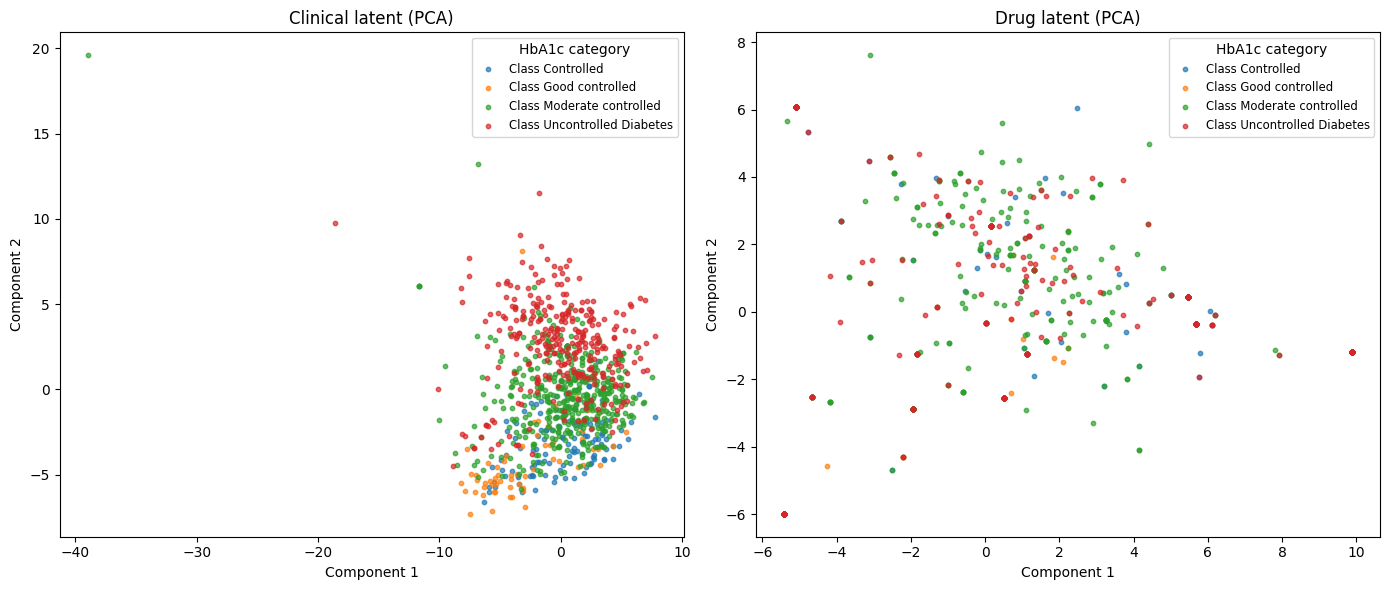

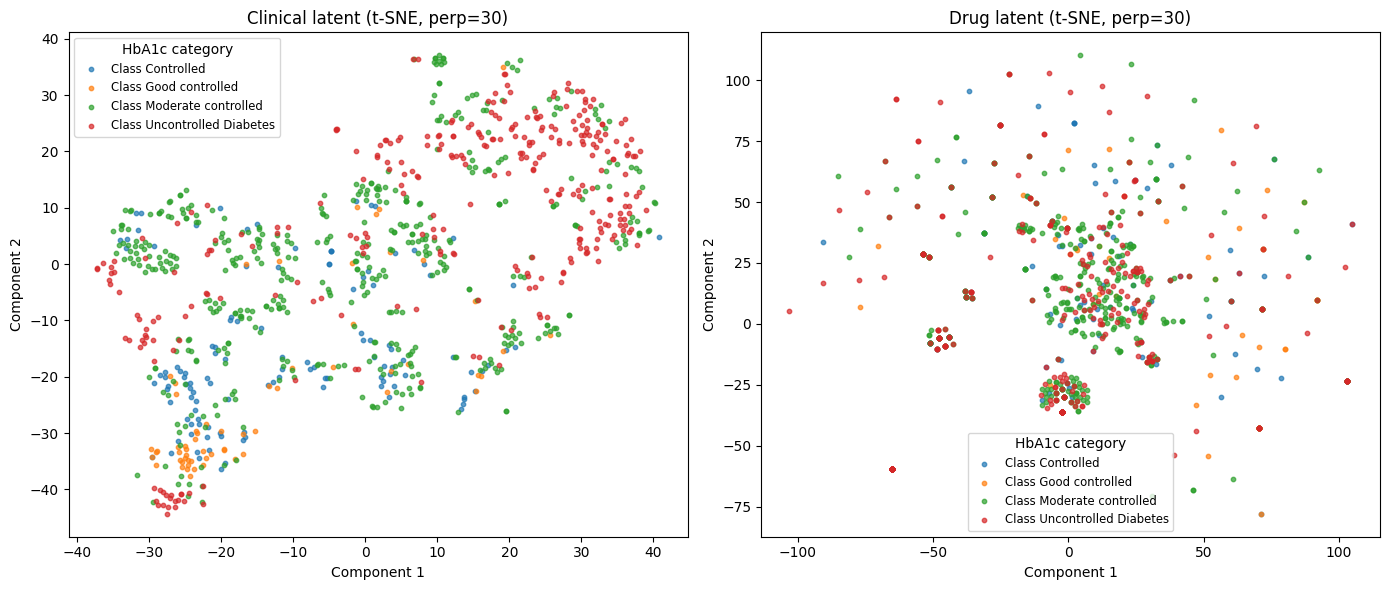

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


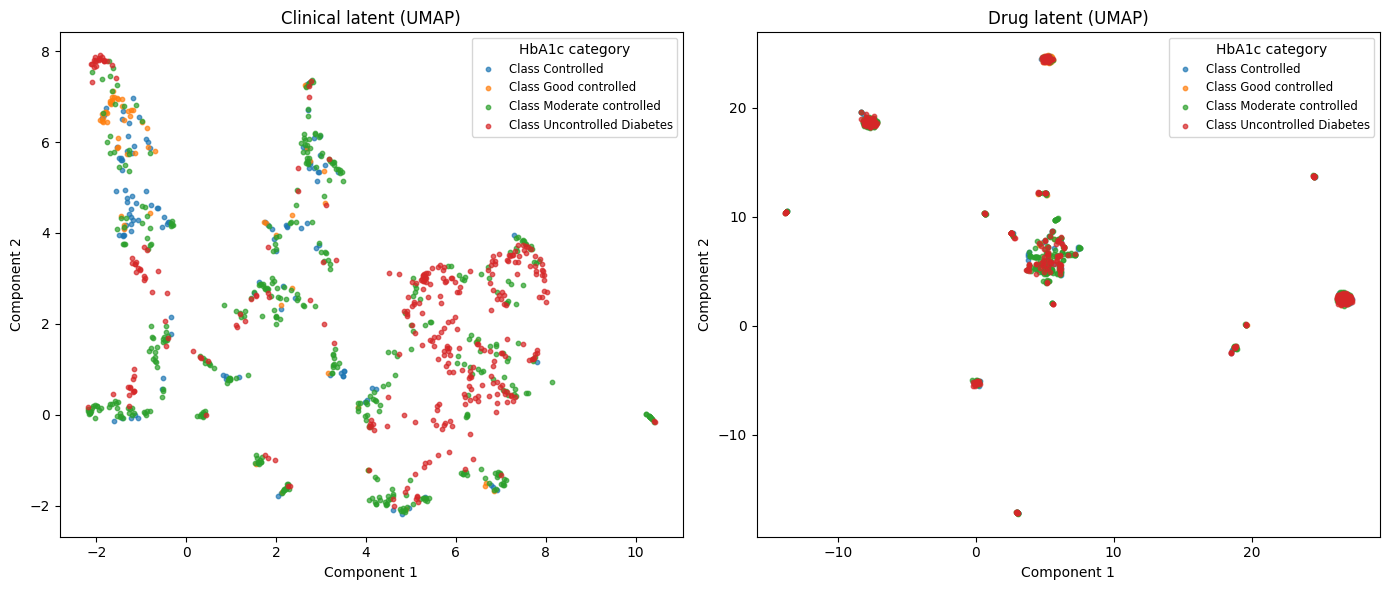

Joint latent shape: (950, 256)


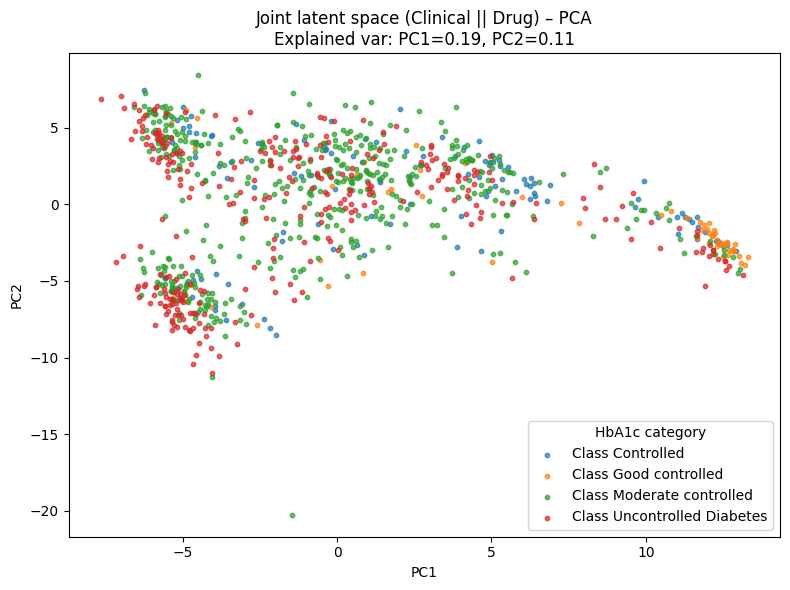

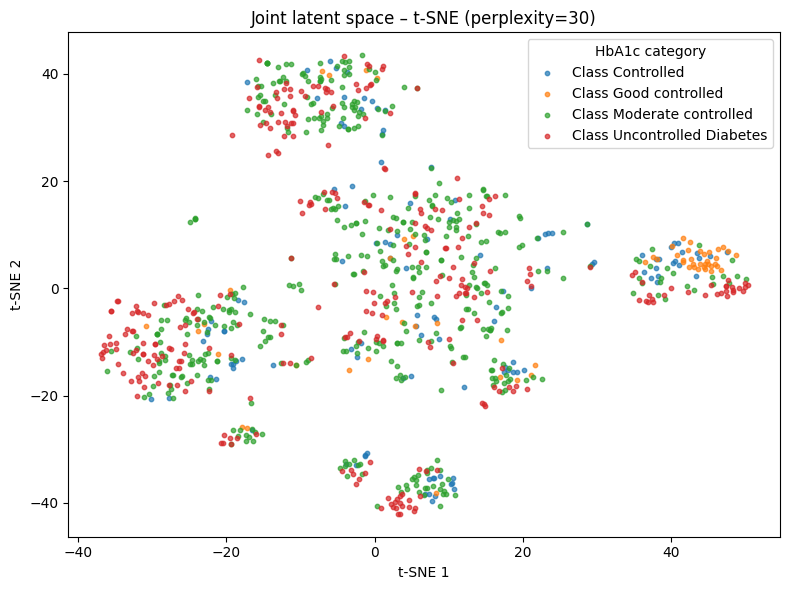

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


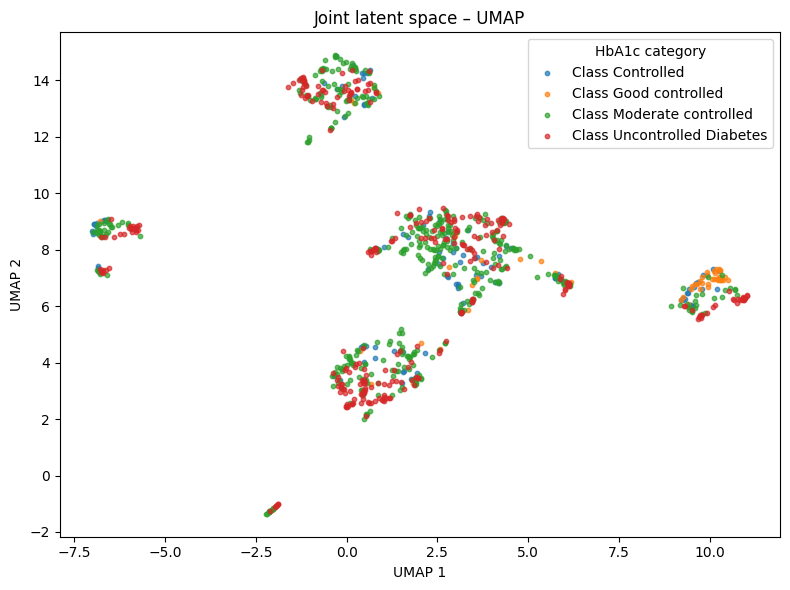


✅ All latent visualisations complete with clear labels.


In [15]:
# ============================================================
# METRICS & LATENT VISUALISATIONS (improved for clarity)
# ============================================================

device = DEVICE

from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

# ------------------------------------------------------------
# 1. Define HbA1c category names (adjust bins to your data!)
# ------------------------------------------------------------
# Example mapping – replace with your actual bins
hba1c_map = {
    0: "Normal (<6.5%)",
    1: "Moderate (6.5–7.5%)",
    2: "High (7.5–9.0%)",
    3: "Very high (>9.0%)"
}
# If you have different numbers, update accordingly.
# To auto‑detect unique values, use:
# unique_cats = sorted(test_df['hba1c_category'].unique())
# then create mapping from those values to names.

def get_category_name(cat_value):
    return hba1c_map.get(cat_value, f"Class {cat_value}")

# ------------------------------------------------------------
# 2. Evaluation function (unchanged)
# ------------------------------------------------------------
def evaluate_mapct_v3_5(model, test_loader, device, threshold=0.3):
    model.eval()
    all_preds = []
    all_labels = []
    align_scores = []
    with torch.no_grad():
        for (Xc, drug_ids, roles, mask, mech_feats, y_drug, y_clin) in tqdm(test_loader, desc="Evaluating v3.5"):
            Xc = Xc.to(device)
            drug_ids = drug_ids.to(device)
            roles = roles.to(device)
            mask = mask.to(device)
            mech_feats = mech_feats.to(device)

            logits, z_clin = model.predict_drugs(Xc)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(y_drug.cpu().numpy())

            z_drug = model.drug_encoder(drug_ids, roles, mask, mech_feats)
            sim = F.cosine_similarity(z_clin, z_drug, dim=1).cpu().numpy()
            align_scores.extend(sim)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    acc = accuracy_score(y_true.flatten(), y_pred.flatten())
    alignment = np.mean(align_scores)

    print("\n" + "="*50)
    print("MAPCT‑v3.5 TEST SET PERFORMANCE")
    print("="*50)
    print(f"Threshold: {threshold}")
    print(f"Precision (micro): {precision:.4f}")
    print(f"Recall    (micro): {recall:.4f}")
    print(f"F1-score  (micro): {f1:.4f}")
    print(f"Accuracy (overall): {acc:.4f}")
    print(f"Clinical‑Drug Alignment (mean cosine): {alignment:.4f}")

    return {'precision': precision, 'recall': recall, 'f1': f1, 'accuracy': acc, 'alignment': alignment}

# Run evaluation
results = evaluate_mapct_v3_5(model, test_loader, device, threshold=0.3)

# ------------------------------------------------------------
# 3. Extract latents from test set
# ------------------------------------------------------------
model.eval()
z_clin_list = []
z_drug_list = []

with torch.no_grad():
    for (Xc, drug_ids, roles, mask, mech_feats, y_drug, y_clin) in test_loader:
        Xc = Xc.to(device)
        drug_ids = drug_ids.to(device)
        roles = roles.to(device)
        mask = mask.to(device)
        mech_feats = mech_feats.to(device)

        _, z_clin = model.predict_drugs(Xc)
        z_drug = model.drug_encoder(drug_ids, roles, mask, mech_feats)

        z_clin_list.append(z_clin.cpu().numpy())
        z_drug_list.append(z_drug.cpu().numpy())

Z_clin = np.vstack(z_clin_list)
Z_drug = np.vstack(z_drug_list)
print(f"Clinical latents shape: {Z_clin.shape}, Drug latents shape: {Z_drug.shape}")

# Get category labels (same order as test_loader)
categories = test_df['hba1c_category'].values[:len(Z_clin)]
unique_cats = np.unique(categories)
# Convert numeric categories to names for legend
category_names = [get_category_name(c) for c in unique_cats]

# ------------------------------------------------------------
# 4. Helper function to plot latent space with color by category
# ------------------------------------------------------------
def plot_latent_space(data, title, ax, category_values, unique_vals, cmap=plt.cm.tab10):
    """
    data: (n_samples, 2) – reduced coordinates
    category_values: array of category codes (same length)
    unique_vals: sorted unique category codes
    """
    for i, cat in enumerate(unique_vals):
        mask = category_values == cat
        ax.scatter(data[mask,0], data[mask,1],
                   label=category_names[i],
                   c=[cmap(i)], alpha=0.7, s=10)
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(title="HbA1c category", loc='best', fontsize='small')

# ------------------------------------------------------------
# 5. PCA – Clinical and Drug (colored by category)
# ------------------------------------------------------------
pca_clin = PCA(n_components=2)
z_clin_pca = pca_clin.fit_transform(Z_clin)
pca_drug = PCA(n_components=2)
z_drug_pca = pca_drug.fit_transform(Z_drug)

fig, axes = plt.subplots(1,2, figsize=(14,6))
plot_latent_space(z_clin_pca, "Clinical latent (PCA)", axes[0], categories, unique_cats)
plot_latent_space(z_drug_pca, "Drug latent (PCA)", axes[1], categories, unique_cats)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. t‑SNE – Clinical and Drug
# ------------------------------------------------------------
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
z_clin_tsne = tsne.fit_transform(Z_clin)
z_drug_tsne = tsne.fit_transform(Z_drug)

fig, axes = plt.subplots(1,2, figsize=(14,6))
plot_latent_space(z_clin_tsne, "Clinical latent (t‑SNE, perp=30)", axes[0], categories, unique_cats)
plot_latent_space(z_drug_tsne, "Drug latent (t‑SNE, perp=30)", axes[1], categories, unique_cats)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. UMAP – Clinical and Drug (if available)
# ------------------------------------------------------------
try:
    reducer = umap.UMAP(random_state=SEED)
    z_clin_umap = reducer.fit_transform(Z_clin)
    z_drug_umap = reducer.fit_transform(Z_drug)

    fig, axes = plt.subplots(1,2, figsize=(14,6))
    plot_latent_space(z_clin_umap, "Clinical latent (UMAP)", axes[0], categories, unique_cats)
    plot_latent_space(z_drug_umap, "Drug latent (UMAP)", axes[1], categories, unique_cats)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("UMAP not installed – skipping clinical/drug UMAP plots.")

# ------------------------------------------------------------
# 8. JOINT LATENT SPACE (Clinical || Drug) with clear labels
# ------------------------------------------------------------
Z_joint = np.concatenate([Z_clin, Z_drug], axis=1)
print(f"Joint latent shape: {Z_joint.shape}")

# ---- PCA on joint space ----
pca_joint = PCA(n_components=2)
Z_joint_pca = pca_joint.fit_transform(Z_joint)
exp_var = pca_joint.explained_variance_ratio_

plt.figure(figsize=(8,6))
for i, cat in enumerate(unique_cats):
    mask = categories == cat
    plt.scatter(Z_joint_pca[mask,0], Z_joint_pca[mask,1],
                label=category_names[i],
                c=[plt.cm.tab10(i)], alpha=0.7, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Joint latent space (Clinical || Drug) – PCA\nExplained var: PC1={exp_var[0]:.2f}, PC2={exp_var[1]:.2f}")
plt.legend(title="HbA1c category")
plt.tight_layout()
plt.show()

# ---- t‑SNE on joint space ----
tsne_joint = TSNE(n_components=2, perplexity=30, random_state=SEED)
Z_joint_tsne = tsne_joint.fit_transform(Z_joint)

plt.figure(figsize=(8,6))
for i, cat in enumerate(unique_cats):
    mask = categories == cat
    plt.scatter(Z_joint_tsne[mask,0], Z_joint_tsne[mask,1],
                label=category_names[i],
                c=[plt.cm.tab10(i)], alpha=0.7, s=10)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Joint latent space – t-SNE (perplexity=30)")
plt.legend(title="HbA1c category")
plt.tight_layout()
plt.show()

# ---- UMAP on joint space ----
try:
    reducer = umap.UMAP(random_state=SEED)
    Z_joint_umap = reducer.fit_transform(Z_joint)

    plt.figure(figsize=(8,6))
    for i, cat in enumerate(unique_cats):
        mask = categories == cat
        plt.scatter(Z_joint_umap[mask,0], Z_joint_umap[mask,1],
                    label=category_names[i],
                    c=[plt.cm.tab10(i)], alpha=0.7, s=10)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title("Joint latent space – UMAP")
    plt.legend(title="HbA1c category")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("UMAP not installed – skipping joint UMAP plot.")

print("\n✅ All latent visualisations complete with clear labels.")